In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
x=torch.arange(0,10,0.01)

In [15]:
y=5*torch.sin(x)

In [16]:
y.shape

torch.Size([1000])

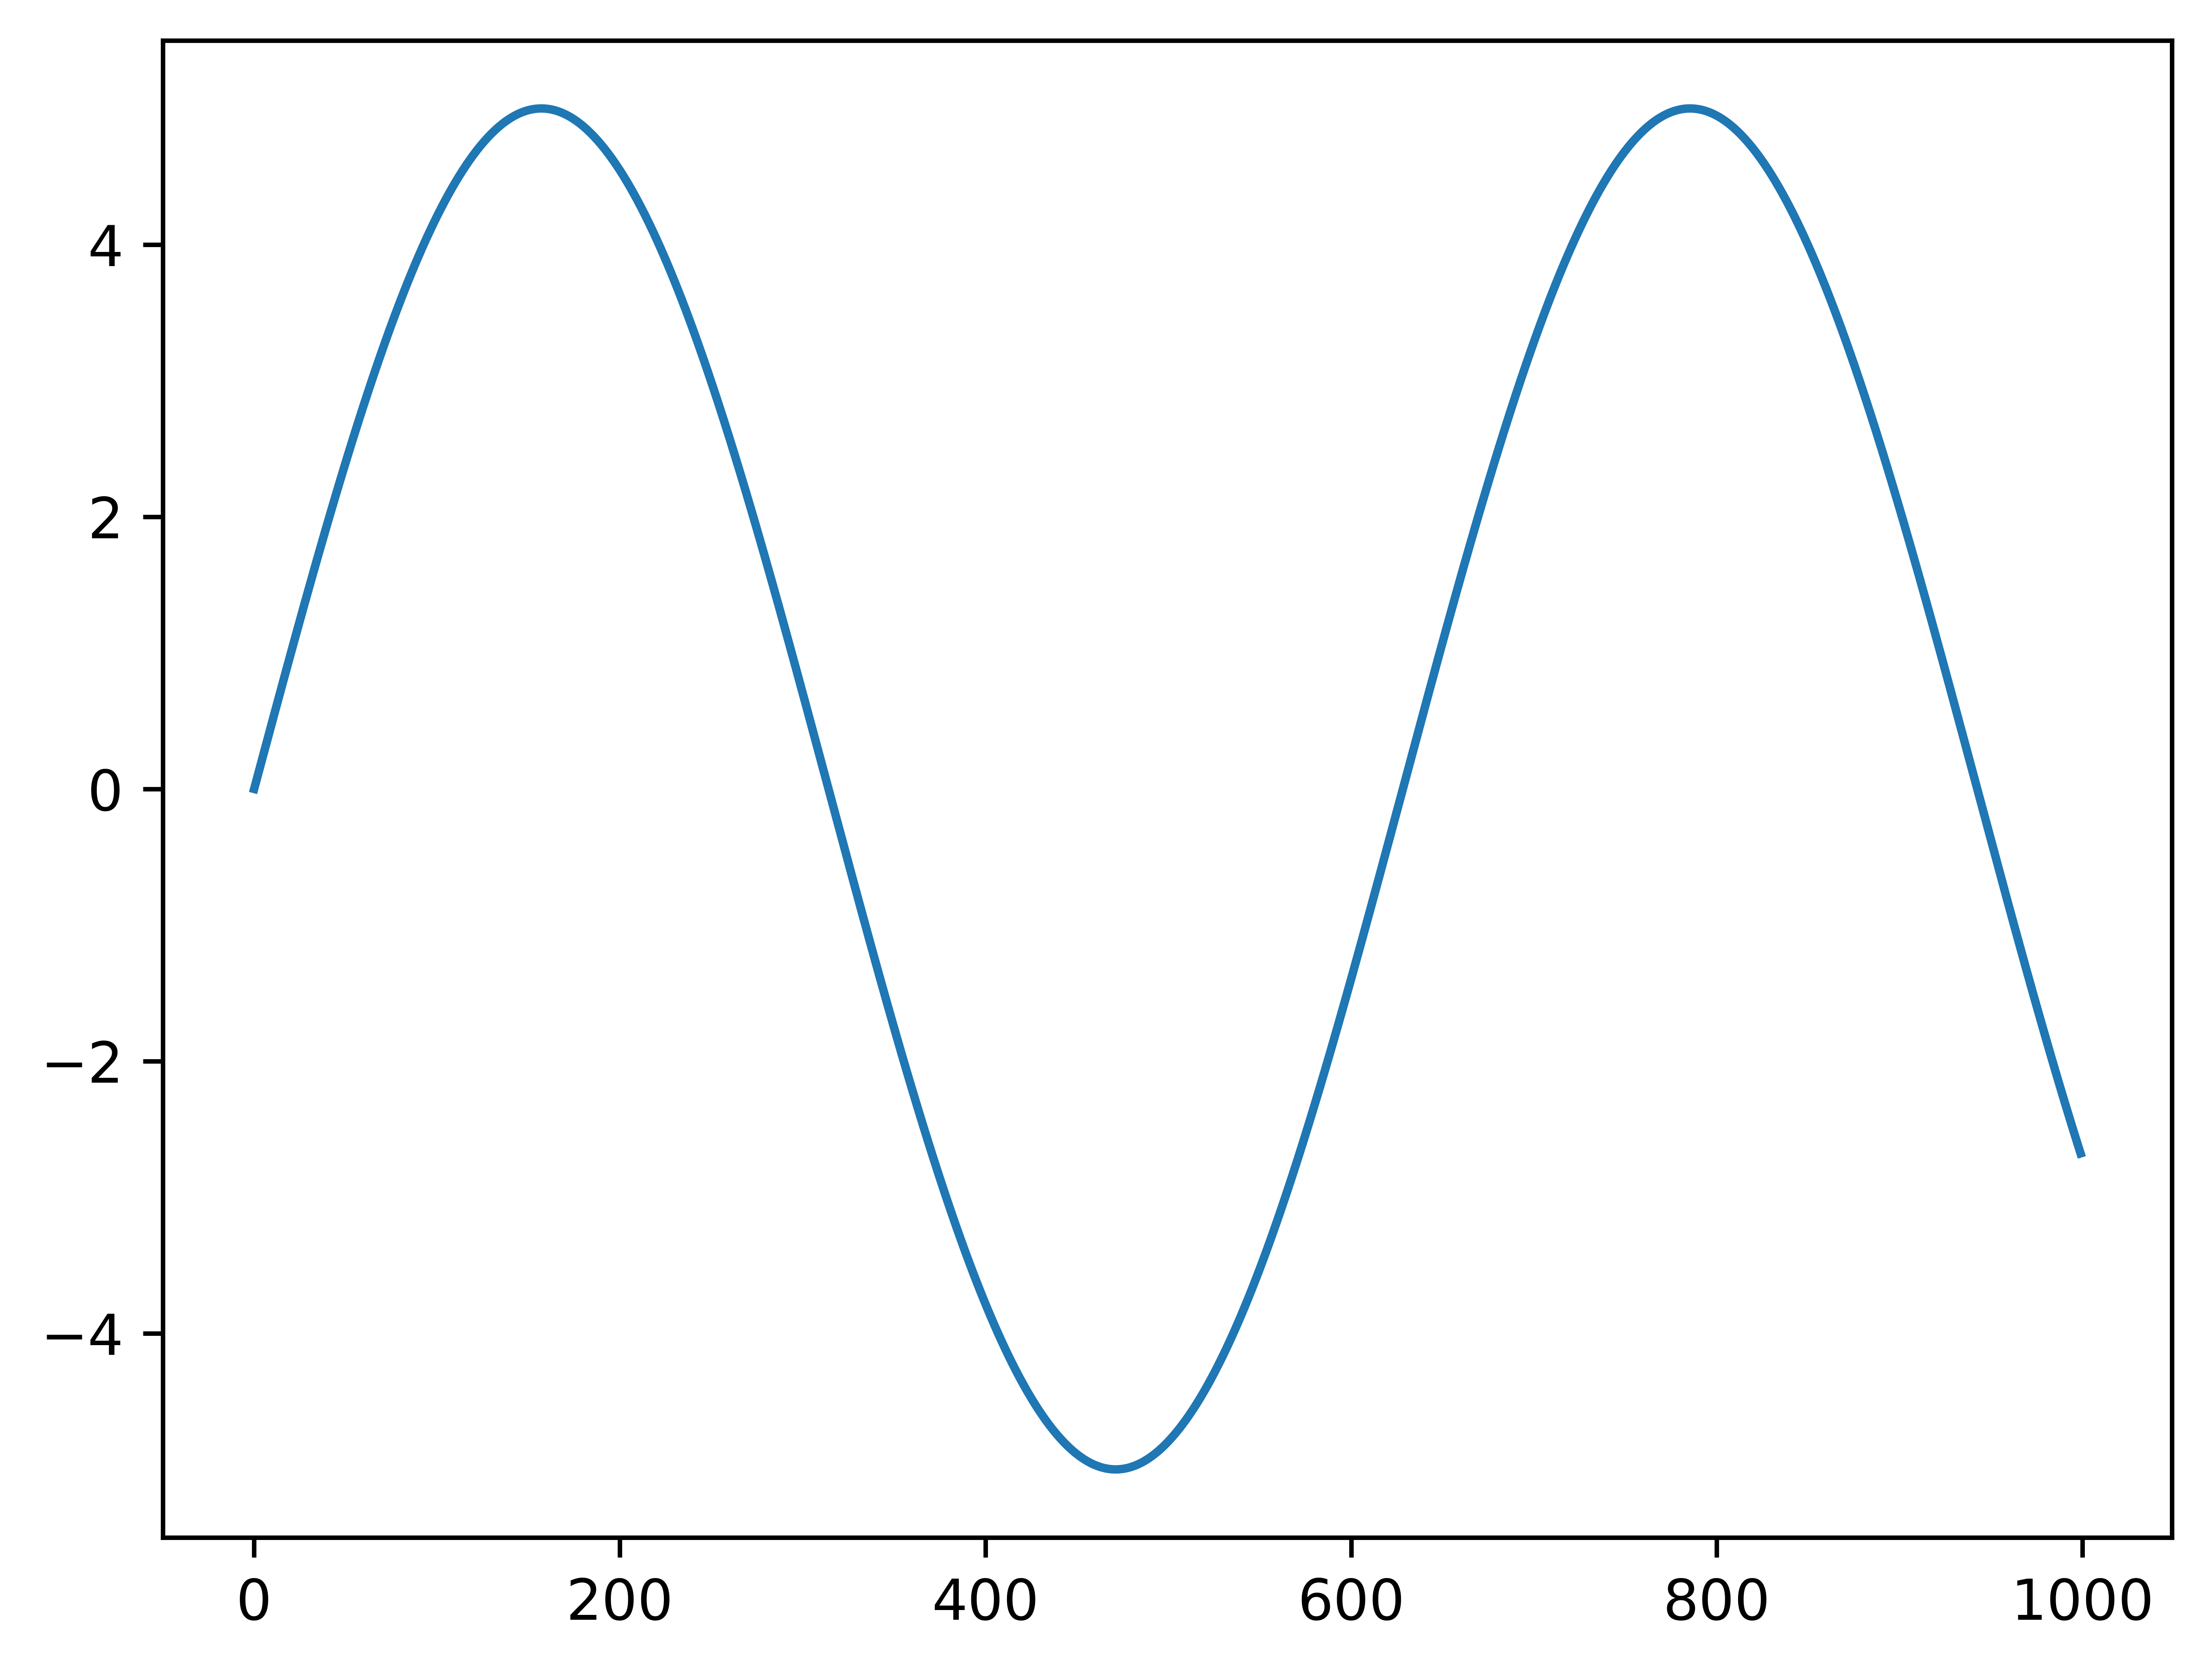

In [17]:
plt.figure(dpi=1000)
plt.plot(y)

In [18]:
split=int(0.8*len(x))
x_train=x[:split].type(torch.float32).to('mps')
y_train=y[:split].type(torch.float32).to('mps')
x_test=x[split:].type(torch.float32).to('mps')
y_test=y[split:].type(torch.float32).to('mps')

In [19]:

model=nn.Sequential(
    nn.Linear(in_features=1,out_features=8),
    nn.ReLU(),
    nn.Linear(in_features=8,out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32,out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16,out_features=4),
    nn.ReLU(),
    nn.Linear(in_features=4,out_features=1),
).to('mps')

    

In [20]:

model=model.to('mps')
model.state_dict()
x_train.shape
x_train.device

device(type='mps', index=0)

In [21]:
epochs=4000
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)
l=[]
for epoch in range(epochs):
    model.train()
    y_pred=model(x_train.unsqueeze(1))
    loss=loss_fn(y_pred,y_train.unsqueeze(1))
    l.append(loss.to('cpu').detach().numpy())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(loss)
y_pred.shape

tensor(3.1442, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1439, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1435, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1431, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1426, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1422, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1417, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1411, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1406, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1399, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1392, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1386, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1380, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1375, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1370, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1366, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1362, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.1359, device='mps:0', grad_fn=<MeanBack

torch.Size([800, 1])

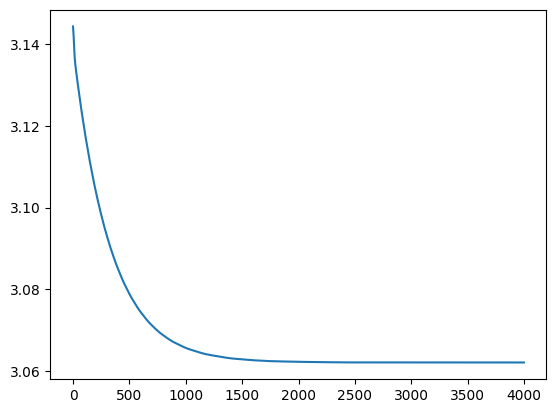

In [22]:
plt.plot(l)

In [23]:
model.eval()
with torch.inference_mode():
    y_p=model(x_test.unsqueeze(1))
    
y_p

    

tensor([[1.3893],
        [1.3892],
        [1.3891],
        [1.3890],
        [1.3889],
        [1.3888],
        [1.3887],
        [1.3886],
        [1.3885],
        [1.3883],
        [1.3882],
        [1.3881],
        [1.3880],
        [1.3879],
        [1.3878],
        [1.3877],
        [1.3876],
        [1.3875],
        [1.3874],
        [1.3873],
        [1.3871],
        [1.3870],
        [1.3869],
        [1.3868],
        [1.3867],
        [1.3866],
        [1.3865],
        [1.3864],
        [1.3863],
        [1.3862],
        [1.3860],
        [1.3859],
        [1.3858],
        [1.3857],
        [1.3856],
        [1.3855],
        [1.3854],
        [1.3853],
        [1.3852],
        [1.3851],
        [1.3849],
        [1.3848],
        [1.3847],
        [1.3846],
        [1.3845],
        [1.3844],
        [1.3843],
        [1.3842],
        [1.3841],
        [1.3840],
        [1.3839],
        [1.3837],
        [1.3836],
        [1.3835],
        [1.3834],
        [1

In [24]:
y1=y_p.to('cpu')

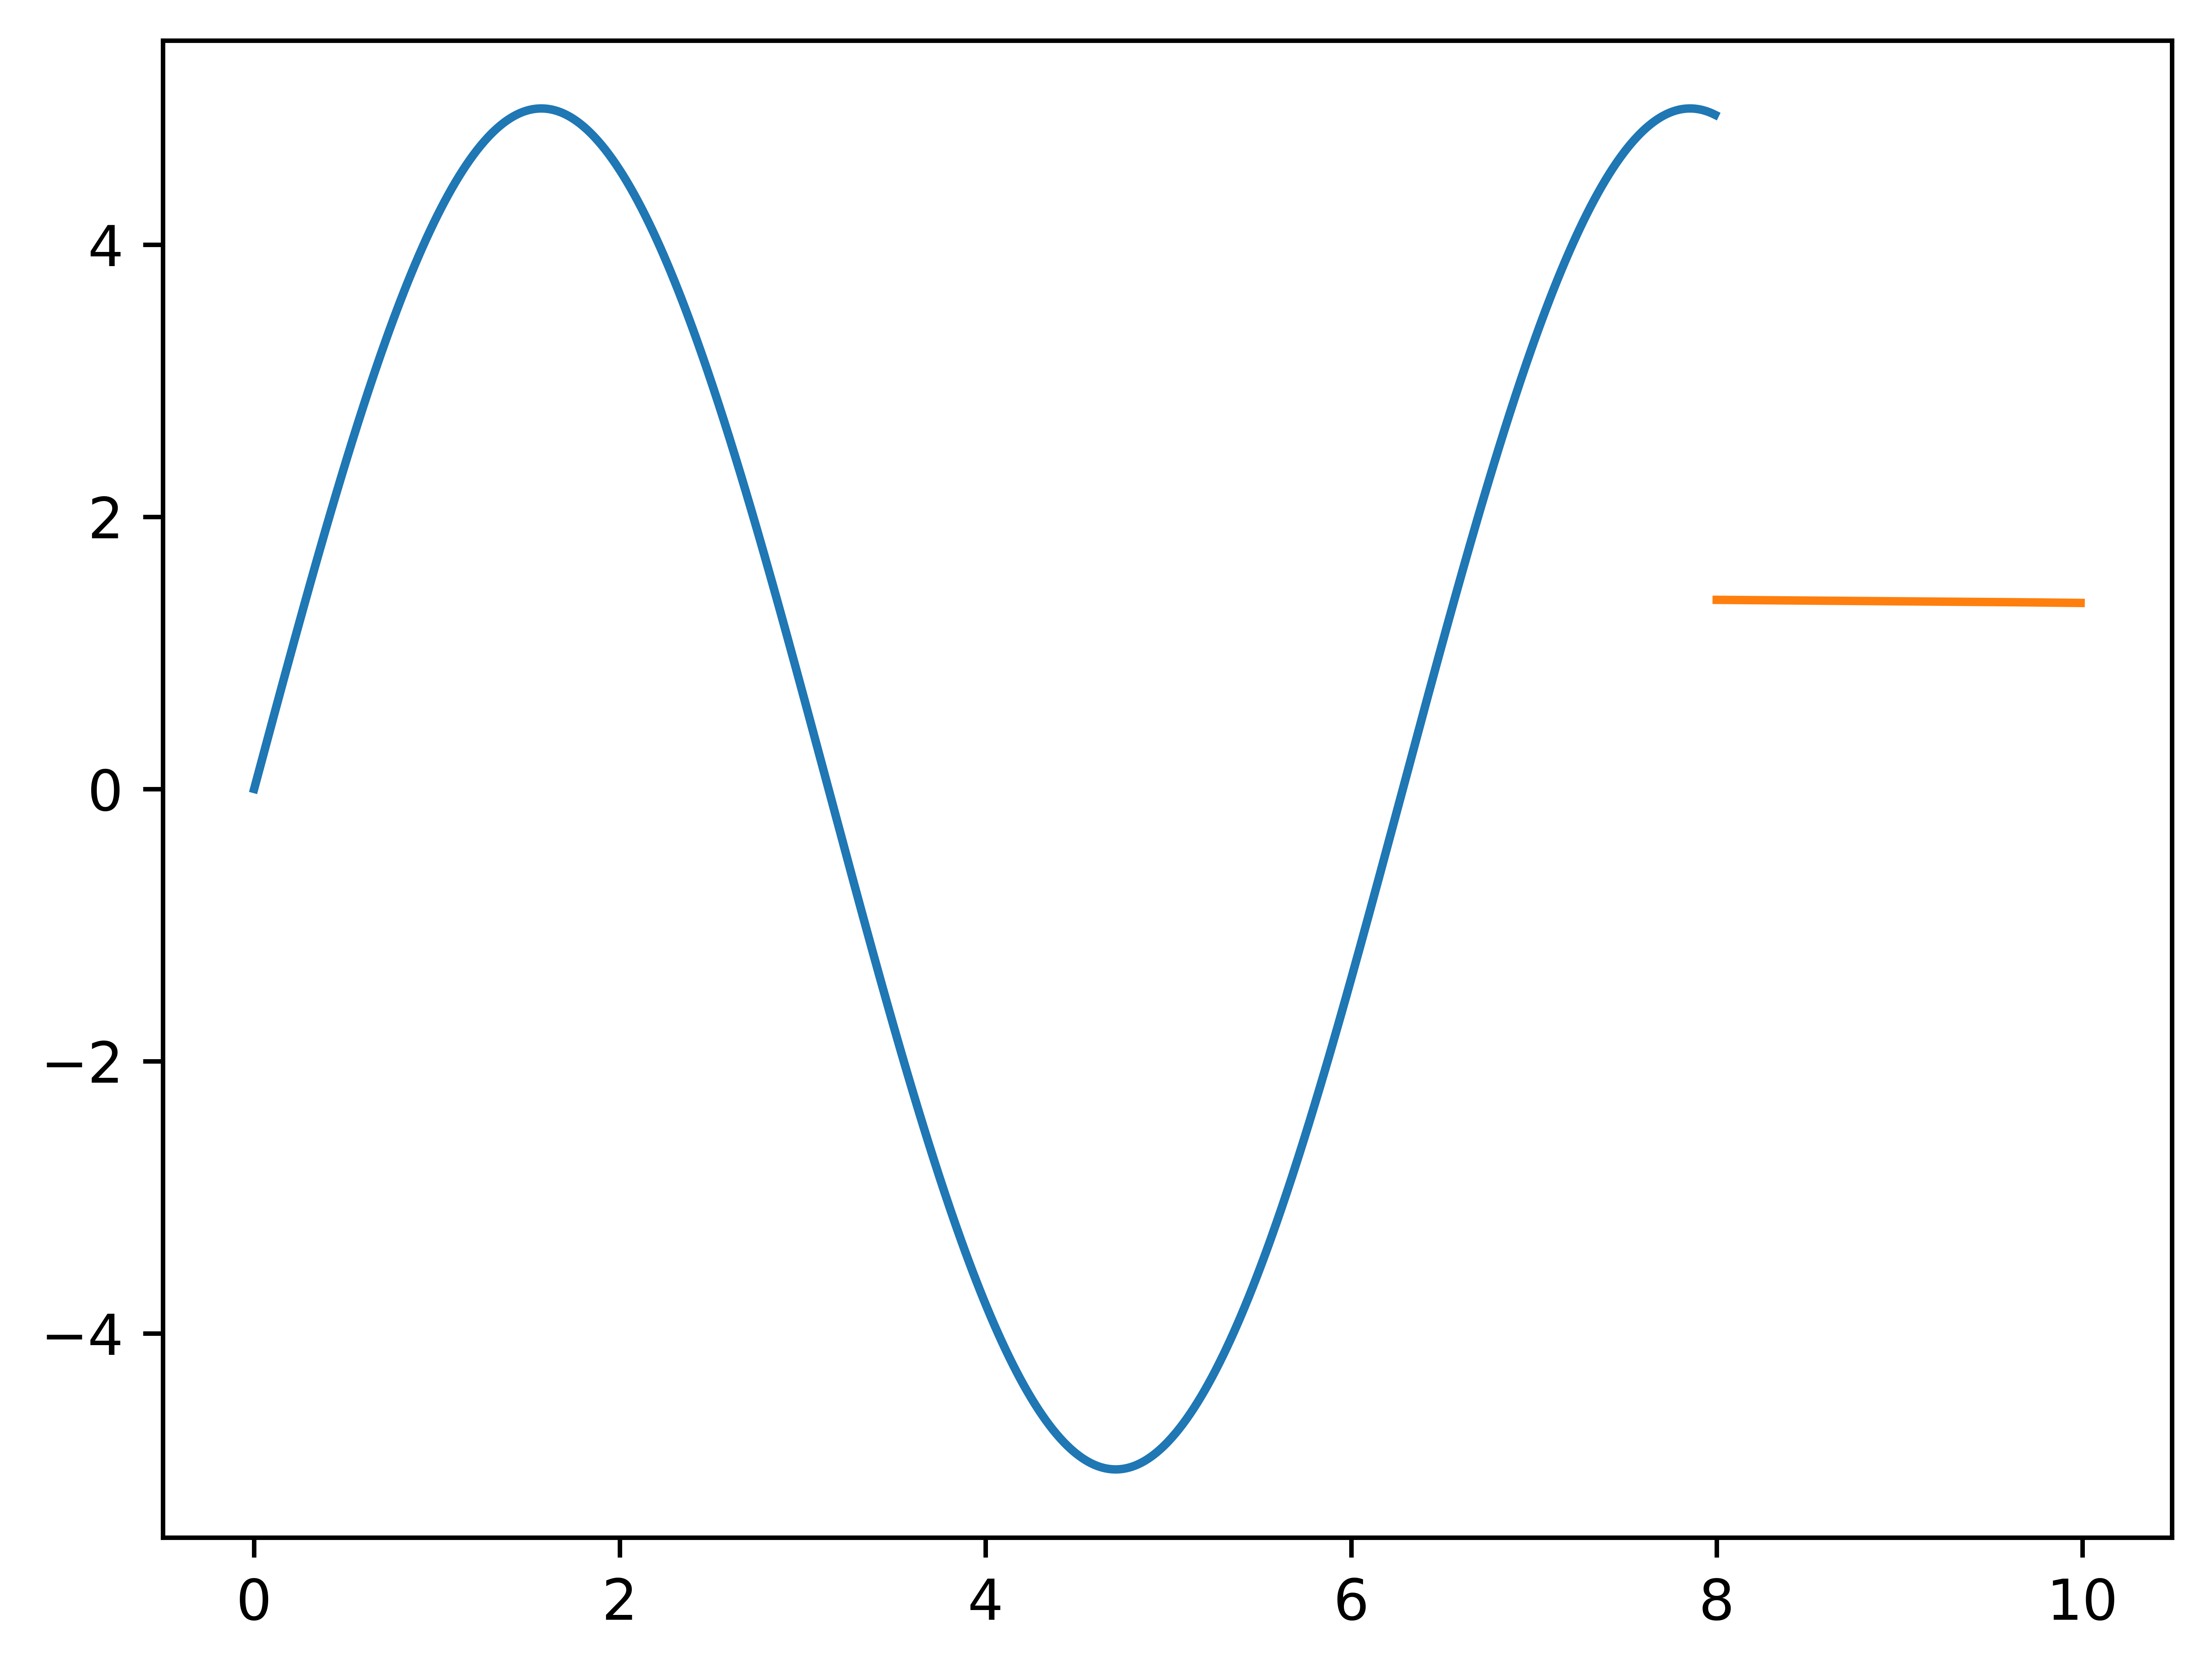

In [25]:
plt.figure(dpi=1000)
plt.plot(x_train.to('cpu'),y_train.to('cpu'))
plt.plot(x_test.to('cpu'),y1)